# 04 — VGG-16 BN (pretrained ImageNet)

In [1]:
import sys
import time
sys.path.insert(0, "..")
sys.path.insert(0, "../experiments")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset, split_dataset,
    get_train_transform, get_eval_transform, build_dataloaders,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, print_model_info,
    compute_multilabel_metrics, evaluate_predictor,
    print_metric_table, NUM_LABELS, METRIC_KEYS,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")


Device: cuda
Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


In [2]:
BASE_DIR        = "../data/aggregated"
IMAGE_SIZE      = 224
BATCH_SIZE      = 32
SPLIT           = [0.7, 0.15, 0.15]
CHECKPOINT_DIR  = Path("../checkpoints")
EXPERIMENT_NAME = "vgg16_pretrained"
MODEL_PATH      = CHECKPOINT_DIR / f"final_{EXPERIMENT_NAME}.pth"

full_dataset = load_dataset(BASE_DIR)
train_raw, val_raw, test_raw = split_dataset(full_dataset, SPLIT, SEED)

train_transform = get_train_transform(IMAGE_SIZE)
eval_transform  = get_eval_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = build_dataloaders(
    train_raw, val_raw, test_raw, train_transform, eval_transform,
    batch_size=BATCH_SIZE,
)
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")


Train: 3180  |  Val: 681  |  Test: 682


## Model Definition

In [3]:
from torchvision import models as tv_models

def create_model(num_labels):
    m = tv_models.vgg16_bn(weights=tv_models.VGG16_BN_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(4096, num_labels)
    return m

print_model_info(create_model(NUM_LABELS))


  Total params     :  134,318,156
  Trainable params :  134,318,156  (100.0%)
  Model size       : 512.38 MB  (float32 weights)


## Grid Search (LR × WD)

In [4]:
GRID = [
    {"lr": 1e-3, "wd": 1e-4},
    {"lr": 1e-3, "wd": 1e-3},
    {"lr": 3e-4, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-4},
]

grid_results = []
for cfg in GRID:
    print(f"\n--- lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e} ---")
    state, val_f1, _, epochs_run = train_model(
        create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
        lr=cfg["lr"], weight_decay=cfg["wd"],
        max_epochs=20, warmup_epochs=2, early_stop_patience=5,
    )
    grid_results.append({**cfg, "val_f1": val_f1, "state": state, "epochs": epochs_run})
    print(f"  => val F1: {val_f1:.4f}")

grid_results.sort(key=lambda x: x["val_f1"], reverse=True)
best = grid_results[0]
print(f"\nBest config: lr={best['lr']:.0e}  wd={best['wd']:.0e}  val_F1={best['val_f1']:.4f}")

rows = [{"lr": c["lr"], "wd": c["wd"], "val_f1": round(c["val_f1"], 4), "epochs": c["epochs"]}
        for c in grid_results]
print(pd.DataFrame(rows).to_string(index=False))



--- lr=1e-03  wd=1e-04 ---

Epoch  1/20  [lr=5.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.3449    0.2893
  exact_match            0.1701    0.2379
  hamming_acc            0.8710    0.8943
  mean_iou               0.2852    0.4223
  precision_micro        0.6486    0.7781
  recall_micro           0.2629    0.3917
  f1_micro               0.3741    0.5211

Epoch  2/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.3459    0.4315
  exact_match            0.1667    0.1204
  hamming_acc            0.8707    0.8595
  mean_iou               0.2829    0.1816
  precision_micro        0.6496    0.5855
  recall_micro           0.2564    0.1483
  f1_micro               0.3677    0.2367

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.3312    0.3430
  e

## Final Training


Epoch  1/60  [lr=2.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4019    0.2746
  exact_match            0.0478    0.2408
  hamming_acc            0.8436    0.8972
  mean_iou               0.0763    0.3814
  precision_micro        0.3455    0.9186
  recall_micro           0.0743    0.3292
  f1_micro               0.1224    0.4847

Epoch  2/60  [lr=4.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2416    0.1740
  exact_match            0.3403    0.4626
  hamming_acc            0.9106    0.9350
  mean_iou               0.5296    0.6766
  precision_micro        0.8299    0.8912
  recall_micro           0.4909    0.6350
  f1_micro               0.6169    0.7416

Epoch  3/60  [lr=6.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.1791    0.1555
  exact_match            0.4730

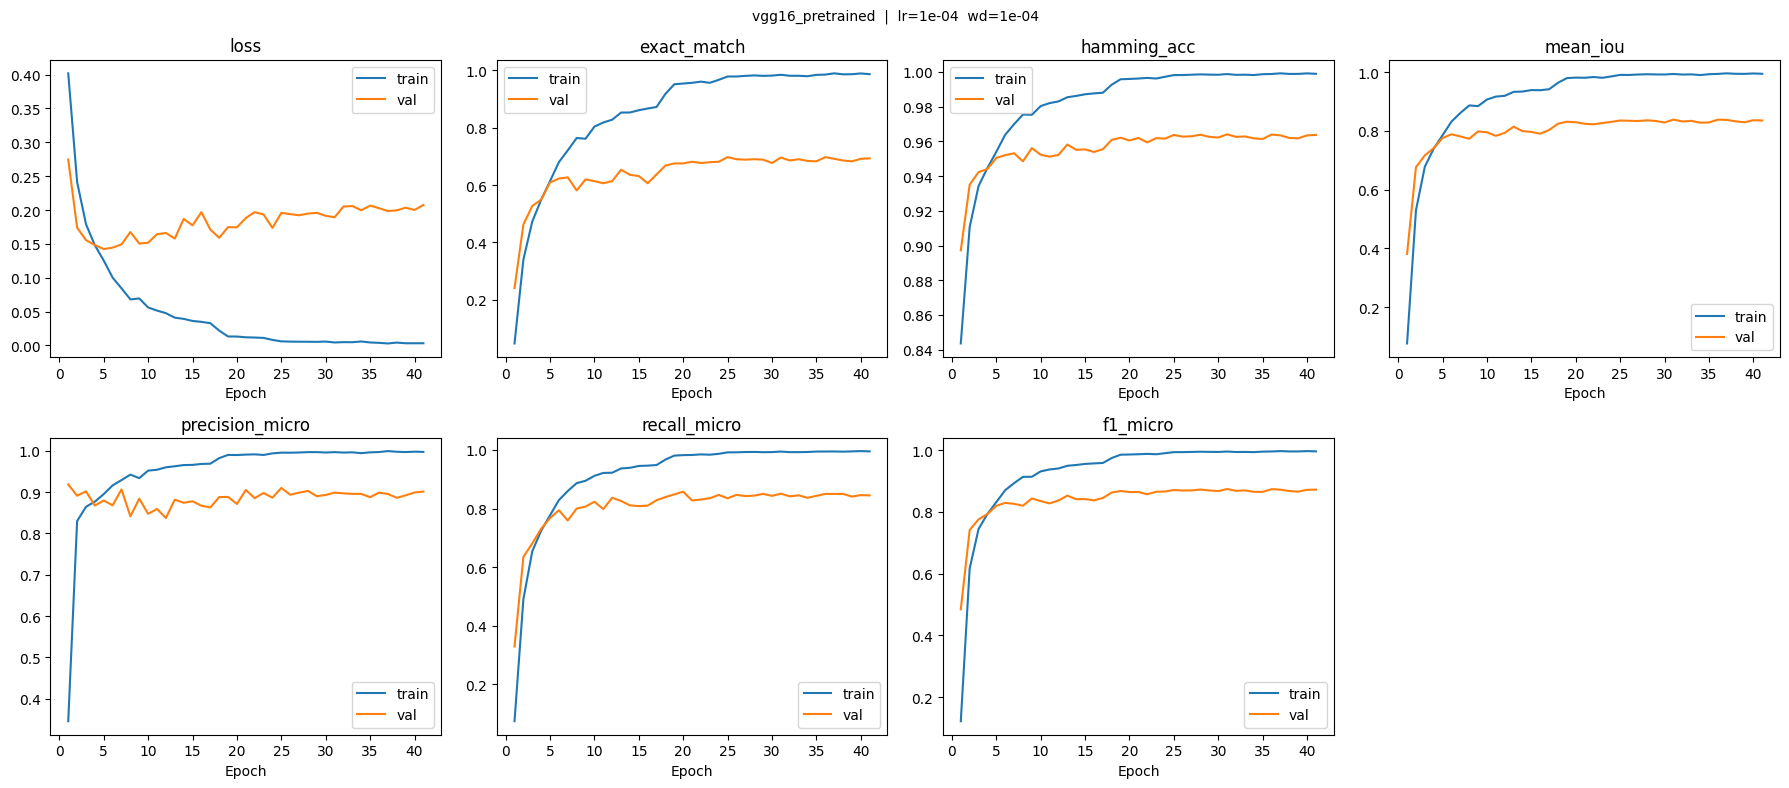

In [5]:
t0 = time.time()
best_state, best_val_f1, history, epochs_run = train_model(
    create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
    lr=best["lr"], weight_decay=best["wd"],
    max_epochs=60, warmup_epochs=5, early_stop_patience=10,
)
training_time = time.time() - t0
print(f"\nBest val F1: {best_val_f1:.4f}  |  Epochs: {epochs_run}  |  Time: {training_time:.1f}s")

save_checkpoint(best_state, MODEL_PATH)
plot_training_history(history, epochs_run, EXPERIMENT_NAME, best["lr"], best["wd"])


## Evaluation

In [6]:
model = load_checkpoint(create_model, NUM_LABELS, MODEL_PATH, DEVICE)
model.eval()

def _predict(images, threshold=0.5):
    with torch.no_grad():
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= threshold).float()
    return preds, probs, logits

val_metrics  = evaluate_predictor(val_loader,  _predict, DEVICE)
test_metrics = evaluate_predictor(test_loader, _predict, DEVICE)

rows = [
    {"split": "val",  **{k: round(val_metrics[k],  4) for k in METRIC_KEYS}},
    {"split": "test", **{k: round(test_metrics[k], 4) for k in METRIC_KEYS}},
]
df = pd.DataFrame(rows).set_index("split")
print(df.to_string())


         loss  exact_match  hamming_acc  mean_iou  precision_micro  recall_micro  f1_micro
split                                                                                     
val    0.1893       0.6960       0.9640    0.8386           0.8988        0.8508    0.8741
test   0.2034       0.7067       0.9629    0.8336           0.8978        0.8405    0.8682


In [7]:

print("\nModel summary:")
print_model_info(create_model(NUM_LABELS))
print(f"Training time : {training_time:.1f}s")



Model summary:
  Total params     :  134,318,156
  Trainable params :  134,318,156  (100.0%)
  Model size       : 512.38 MB  (float32 weights)
Training time : 1792.1s
